In [1]:
import numpy as np
import matplotlib.pyplot as plt
import scipy
from spectral_method_1d_utils import quadratic_taylor_terms, angular_spectrum_method

In [ ]:
def semi_analytical_asm(E, z, k2, Nx, dx, x):
    """
    Angular spectruum method from: https://rafael-fuente.github.io/simulating-diffraction-patterns-with-the-angular-spectrum-method-and-python.html

    Modified by Karthik Sreekumar
    """

    # ---------------------------
    # Forward semi analytical FFT
    # ---------------------------

    # computing quadratic and residual phase
    phase = np.atan2(E.imag, E.real)
    Cxx = quadratic_taylor_terms(phase, Nx, dx)
    phase_quad = Cxx*x*x
    residual_phase = phase - phase_quad

    U = np.abs(E) * np.exp(1j*residual_phase)

    # calculating analytical part of fourier transform
    kx = 2 * np.pi * scipy.fft.fftshift(scipy.fft.fftfreq(Nx, d = dx))

    Cxx_inv = -1/(4*Cxx)
    phase_quad_inv = Cxx_inv*kx*kx
    plt.plot(phase_quad_inv)
    plt.title("inverse phase")
    plt.show()
    alpha = np.sqrt(1j / (2* Cxx))
    print("Forward semi analytical transform: Cxx=", Cxx, "Cxx_inv=", Cxx_inv)

    # compute forward semi analytical FFT
    fft_c = scipy.fft.fft(U)
    c = scipy.fft.fftshift(fft_c)
    U = c * np.exp(1j * phase_quad_inv)
    plt.plot(np.angle(c), label = 'c')
    plt.plot(np.angle(U), label = 'U')
    plt.plot(np.angle(np.exp(1j * phase_quad_inv)), label="quadratic_phase")
    plt.legend()
    plt.show()
    E = alpha * scipy.fft.ifft(scipy.fft.ifftshift(U)) * np.exp(1j * phase_quad_inv)
    plt.plot(np.angle(E))
    plt.title("fourier space")
    plt.show()

    argument = k2 - kx*kx
    #Calculate the propagating and the evanescent (complex) modes
    tmp = np.sqrt(argument)
    # kz = np.where(argument >= 0, tmp, 1j*tmp)
    kz = tmp

    # propagate the angular spectrum a distance z
    E = E * np.exp(1j * kz* z)
    # E = np.fft.ifft2(c)

    # ---------------------------
    # Inverse semi analytical FFT
    # ---------------------------

    # computing quadratic and residual phase
    phase = np.atan2(E.imag, E.real)
    Cxx_inv= quadratic_taylor_terms(phase, Nx, np.abs(kx[1] - kx[0]))
    phase_quad_inv = Cxx_inv*kx*kx
    residual_phase = phase - phase_quad_inv

    U = np.abs(E) * np.exp(1j * residual_phase)
    Cxx = -1/(4*Cxx_inv)
    phase_quad = Cxx*x*x
    print("Inverse semi analytical transform: Cxx=", Cxx, "Cxx_inv=", Cxx_inv)

    alpha_inv = np.sqrt(1j / (2*Cxx_inv))

    # compute inverse semi analytical FFT
    fft_c = scipy.fft.ifft(U)
    c = scipy.fft.ifftshift(fft_c)

    U = c * np.exp(1j * phase_quad)
    E = alpha_inv * scipy.fft.fft(scipy.fft.fftshift(U)) * np.exp(1j * phase_quad)

    print(alpha, alpha_inv)

    return E

In [126]:
params = {}
with open("/home/karthik/Desktop/Thesis/UGBlocks_V4_Oct_21_2025/program2D/para.dat") as f:
    lines = f.readlines()
    for item in lines:
        item = item.split()
        params[item[0]] = float(item[1])
n0 = params["n0_real"] + 1j*params["n0_imag"]
n2 = params["n2_real"] + 1j*params["n2_imag"]
# n2 *= 1e6
wavelength_0 = params["wavelength"]
wavelength = wavelength_0 / n0.real
steps = int(params["steps"])
levelFFT = int(params["levelFFT"])
typ = params["typ"]
zScreen = params["zScreen"]
radiusGeo = params["radiusGeo"]
SG = params["SG"]
material = params["material"]
angle = params["angle"]
zw = params["zw"]
step = zScreen/steps

In [127]:
angle = np.asin(np.sin(angle)/n0.real)
w0 = wavelength / (np.pi * np.tan(angle))
a = -zw
b = np.pi * w0 * w0 / wavelength #wavelength / (M_PI * tan(angleRad) * tan(angleRad))   #Rayleigh length
R = (a*a+b*b)/a                                       #Radius of curvature
wavenumber =  2.0 * np.pi * n0 / wavelength_0  
w = np.sqrt(2.0 * (a*a+b*b) / (b * wavenumber.real))          #Beam radius
wSG = w
length = 2**levelFFT
h = 2*radiusGeo / length
x = np.linspace(-radiusGeo, radiusGeo-h, int(2**levelFFT))

print(f"a={a}, b={b}, w0={w0}, w={w}, R={R}, levelFFT={levelFFT}, n0={n0}, n2={n2}")

a=2.0, b=2167.562969911326, w0=0.677363432948198, w=0.6773637212903962, R=2349166.614265404, levelFFT=6, n0=(1.6+0j), n2=0j


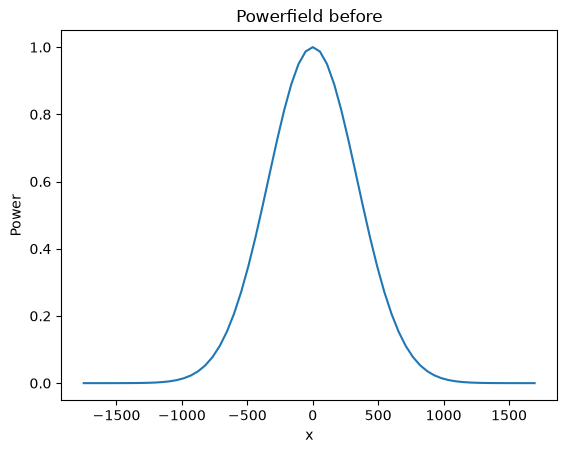

In [128]:
E = np.exp(-(np.sqrt(x*x) / wSG)**SG)
E = E* np.exp(-1j*wavenumber * (x*x) / (2*R))
powerField = np.abs(E**2)
plt.plot(x*1e3,powerField)
plt.xlabel("x")
plt.ylabel("Power")
plt.title("Powerfield before")
plt.show()

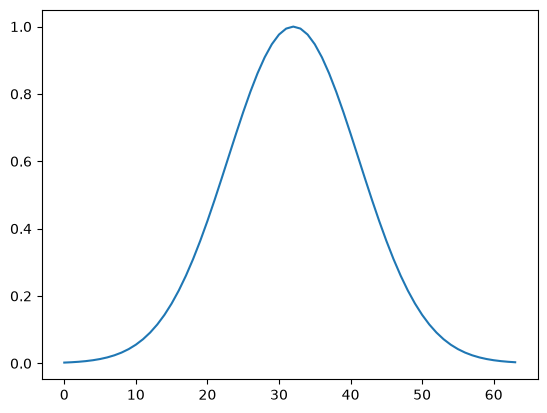

In [129]:
plt.plot(np.exp(-2*x*x))

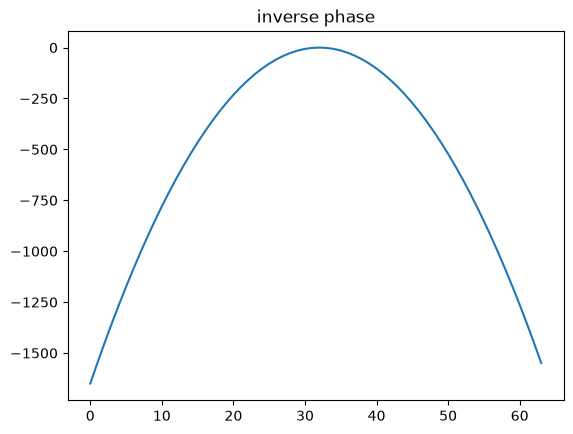

Forward semi analytical transform: Cxx= 0.5 Cxx_inv= -0.5


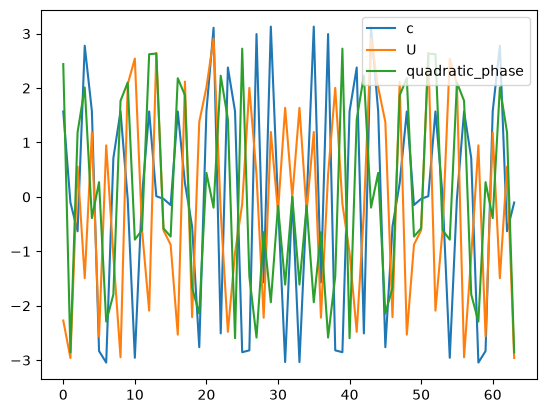

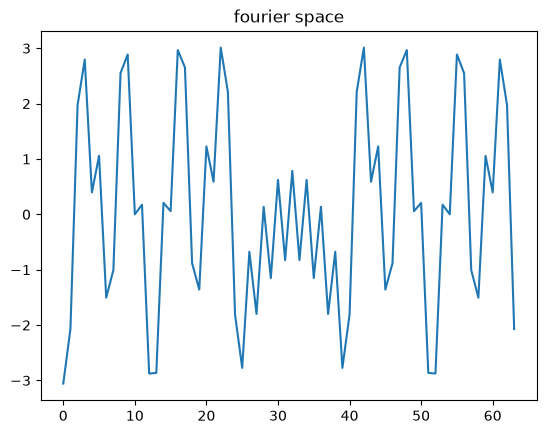

Inverse semi analytical transform: Cxx= 0.500000000000004 Cxx_inv= -0.49999999999999606
(0.7071067811865476+0.7071067811865476j) (0.7071067811865503-0.7071067811865503j)


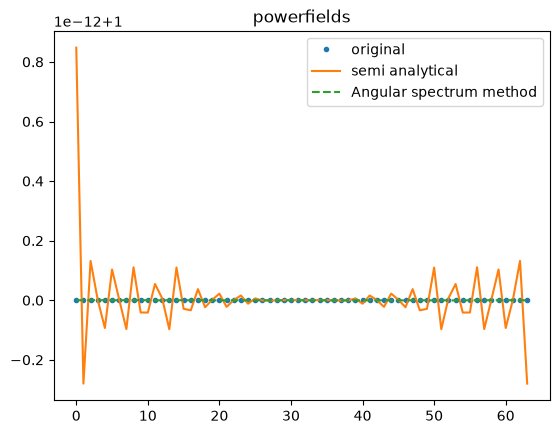

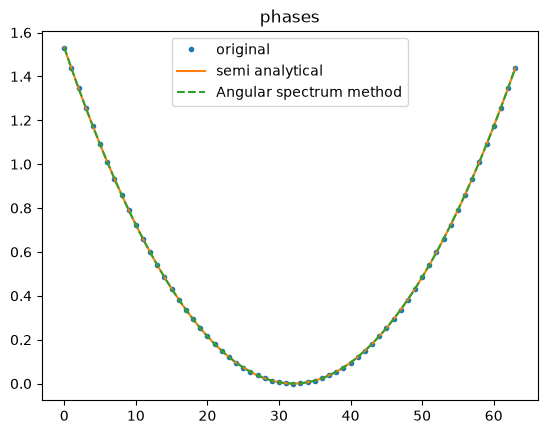

Quadratic factor after ASM: 0.49999999999993894
Quadratic factor after semi analytical ASM: 0.499999999995292


In [130]:
k2 = wavenumber*wavenumber
dx = radiusGeo*2 / (2**levelFFT)
E = np.exp(1j/2 * x * x )
E_semi = semi_analytical_asm(E, 0, k2, int(2**levelFFT), dx, x)
E_asm = angular_spectrum_method(E, 0, k2, int(2**levelFFT), dx)
plt.plot(np.abs(E)**2, '.', label = "original")
plt.plot(np.abs(E_semi)**2, label="semi analytical")
plt.plot(np.abs(E_asm)**2, '--', label="Angular spectrum method")
plt.legend()
plt.title("powerfields")
plt.show()

plt.plot(np.angle(E), '.', label = "original")
plt.plot(np.angle(E_semi), label="semi analytical")
plt.plot(np.angle(E_asm), '--', label="Angular spectrum method")
plt.legend()
plt.title("phases")
plt.show()

print("Quadratic factor after ASM:", quadratic_taylor_terms(np.angle(E_asm), length, dx))
print("Quadratic factor after semi analytical ASM:", quadratic_taylor_terms(np.angle(E_semi), length, dx))

In [ ]:
def quadratic_fourier(Cxx, x, Nx, dx):
    Cxx_inv = -1/(4*Cxx)
    alpha = np.sqrt(1j / (2*Cxx))
    kx = 2 * np.pi * scipy.fft.fftshift(scipy.fft.fftfreq(Nx, d=dx))
    E_anal = alpha * np.exp(1j * Cxx_inv * kx * kx)
    E = np.exp(1j * Cxx * x * x)
    plt.plot(np.angle(E))
    plt.show()
    E_fft = scipy.fft.fftshift(scipy.fft.fft(E))
    plt.plot(kx,np.abs(E_fft), label="fft")
    plt.plot(kx,np.abs(E_anal), label="analytical")
    plt.title("fourier space")
    plt.legend()
    plt.show()
    alpha_inv = np.sqrt(1j / (2 * Cxx_inv))
    Cxx = -1 / (4*Cxx_inv)
    E_anal = alpha_inv * alpha * np.exp(1j * Cxx * x * x)
    E_fft = scipy.fft.ifft(scipy.fft.ifftshift(E_fft))
    plt.plot(x, np.atan2(E_fft.imag, E_fft.real), label="fft")
    plt.plot(x, np.atan2(E_anal.imag, E_anal.real), label="analytical")
    plt.legend()
    plt.show()

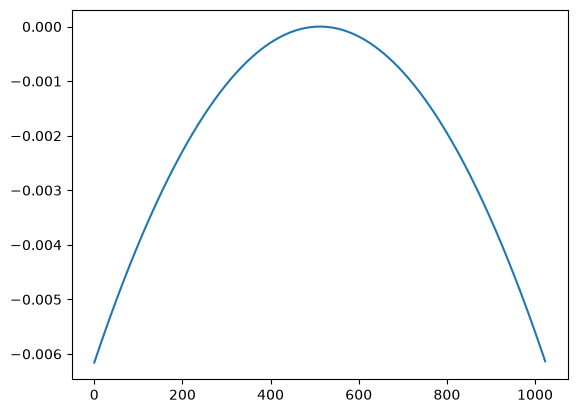

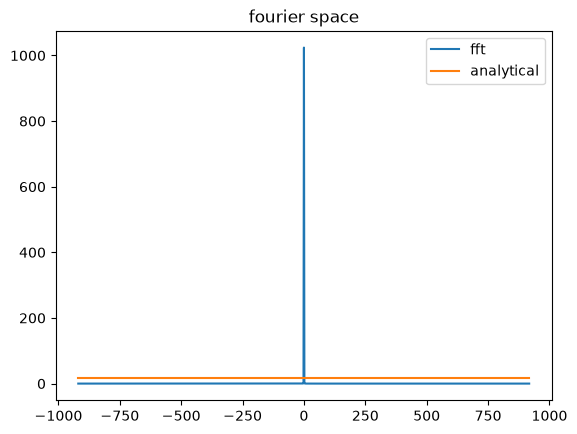

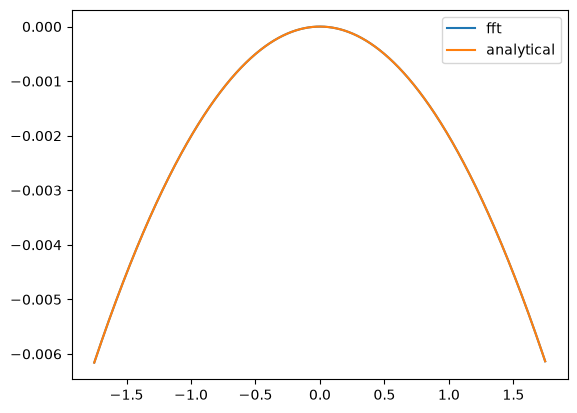

In [ ]:
k2 = wavenumber*wavenumber
length = int(2**10)
dx = radiusGeo*2 / length
h = 2*radiusGeo / length
quadratic_fourier(-0.002011, np.linspace(-radiusGeo, radiusGeo-h, length), length, dx)

Cxx= -2011.0108199199337 Cxx_inv= 0.0001243155917032577


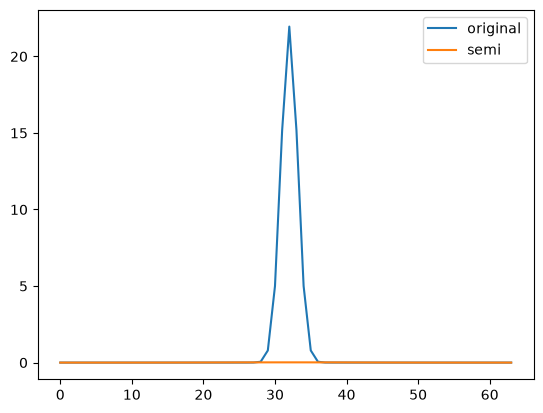

(0.011149690206604742-0.011149690206604742j) (735.3679392810478-735.3679392810478j)


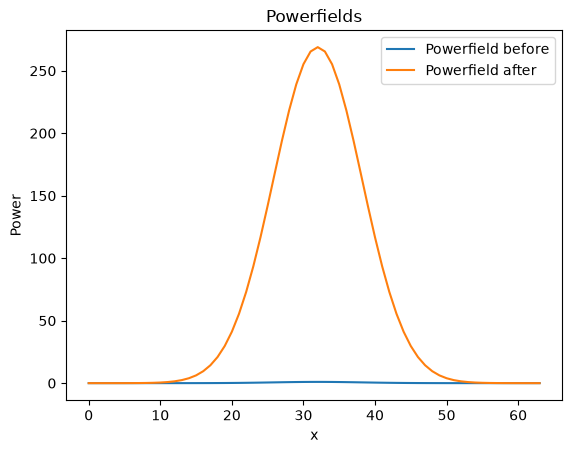

In [7]:
k2 = wavenumber*wavenumber
dx = radiusGeo*2 / (2**levelFFT)
E = semi_analytical_asm(E, step, k2, int(2**levelFFT), dx, x)

powerField2 = np.abs(E**2)
plt.plot(powerField, label = "Powerfield before")
plt.plot(powerField2, label = "Powerfield after")
plt.xlabel("x")
plt.ylabel("Power")
plt.title("Powerfields")
plt.legend()
plt.show()

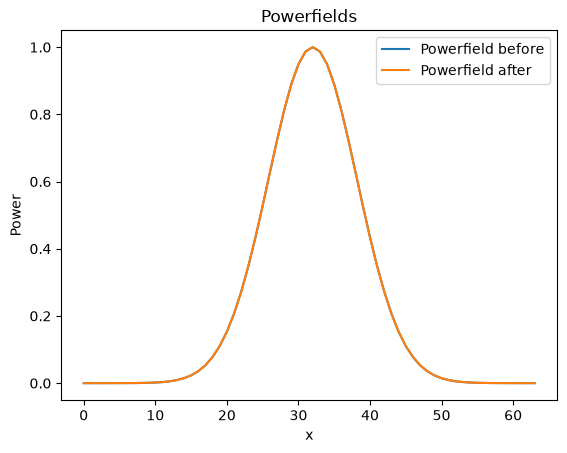

In [5]:
k2 = wavenumber*wavenumber
dx = radiusGeo*2 / (2**levelFFT)
E = angular_spectrum_method(E, step, k2, int(2**levelFFT), dx)

powerField2 = np.abs(E**2)
plt.plot(powerField, label = "Powerfield before")
plt.plot(powerField2, label = "Powerfield after")
plt.xlabel("x")
plt.ylabel("Power")
plt.title("Powerfields")
plt.legend()
plt.show()